In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

In [135]:
!pip install kagglehub --quiet

import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download('adityakadiwal/water-potability')


files = os.listdir(path)
df = pd.read_csv(os.path.join(path, files[0]))

print(f"Dataset loaded successfully: {df.shape}")

Using Colab cache for faster access to the 'water-potability' dataset.
Dataset loaded successfully: (3276, 10)


In [136]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [137]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [138]:
df.dtypes

,0
ph,float64
Hardness,float64
Solids,float64
Chloramines,float64
Sulfate,float64
Conductivity,float64
Organic_carbon,float64
Trihalomethanes,float64
Turbidity,float64
Potability,int64


The datatypes of the dataset are all continuous values(int or float). This means no need for encoding

In [139]:
df.shape

(3276, 10)

The dataset consists of 3276 rows and 10 columns

In [140]:
df['Potability'].value_counts()

,count
Potability,
0,1998
1,1278


In [141]:
df['Potability'].value_counts(normalize=True) * 100

,proportion
Potability,
0,60.989011
1,39.010989


The percentage of good water quality with that of bad water quality is 60.9% to 39&. This implies that the dataset is imbalanced and the imbalance needs handling.

This dataset is about water quality portability.

In developed countries water safety is largely taken for granted. But globally 2 billion people live without access to safe drinking water. Contaminated water causes cholera, typhoid, dysentery and countless other diseases that kill millions annually — many of them children.

Water quality is a very important factor in everyone's health. Before water is made availble for cleaning, it has to undergo some water treatment before it is made available to the public. This dataset consists of features that affects the quality of water in one way or the other from pH value to  the last feature which is turbidity.

The target column is Potability which means after scientists have carried out these treatments, can say if the water is good for drinkingor bad. 1 represents good water quality while 0 represents bad water quality.

TASK 2 - DATA CLEANING AND PREPROCESSING

In [142]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


The columns, ph, Sulfate and Trihalomethanes all have missing values an needs to be cleaned.

In [143]:
print(f"Number of duplicate rows : {df.duplicated().sum()}")

Number of duplicate rows : 0


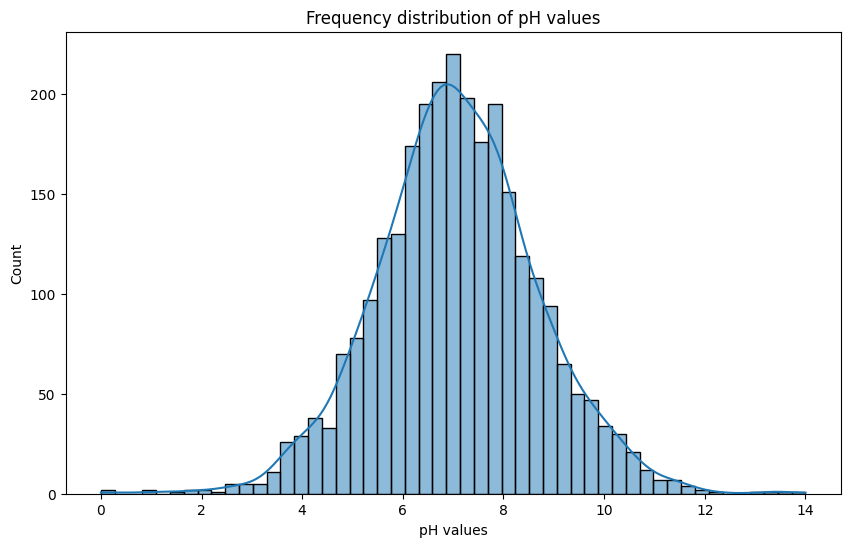

In [144]:
plt.figure(figsize=(10,6))
sns.histplot(df["ph"], edgecolor="black", kde=True)
plt.xlabel("pH values")
plt.ylabel("Count")
plt.title("Frequency distribution of pH values")
plt.show()

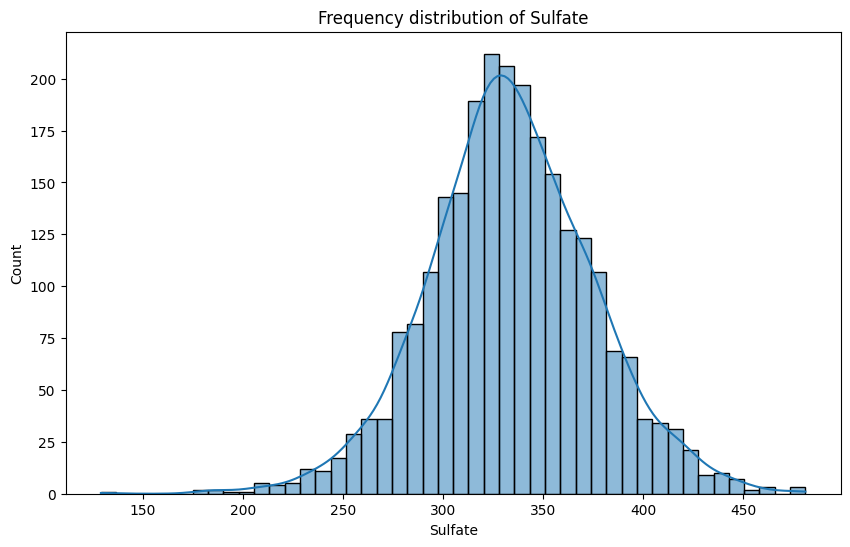

In [145]:
plt.figure(figsize=(10,6))
sns.histplot(df["Sulfate"], edgecolor="black", kde=True)
plt.xlabel("Sulfate")
plt.ylabel("Count")
plt.title("Frequency distribution of Sulfate")
plt.show()

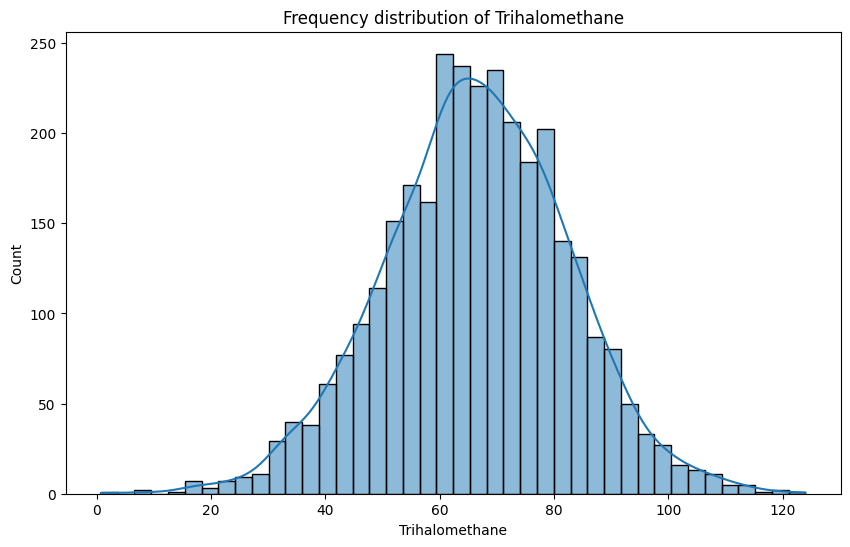

In [146]:
plt.figure(figsize=(10,6))
sns.histplot(df["Trihalomethanes"], edgecolor="black", kde=True)
plt.xlabel("Trihalomethane")
plt.ylabel("Count")
plt.title("Frequency distribution of Trihalomethane")
plt.show()

In [147]:
# ph is normally distributed, fill with mean
df['ph'] = df['ph'].fillna(df["ph"].mean())

# Sulfate is more skewed, so we fill missing values with median
df["Sulfate"] = df["Sulfate"].fillna(df["Sulfate"].median())

#Trihalomethanes is also normally distributed so we fill with the mean
df["Trihalomethanes"] = df["Trihalomethanes"].fillna(df["Trihalomethanes"].mean())

In [148]:
df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [149]:
# Feature engineering
# 1 = Good quality (WHO safe range)
# 0 = Bad quality (outside safe range)
df['ph_quality'] = df['ph'].apply(lambda x: 1 if 6.5 <= x <= 8.5 else 0)

print(df['ph_quality'].value_counts())

ph_quality
1    1819
0    1457
Name: count, dtype: int64


This new feature was engineered because safe drinking water falls within the range of 6.5 to 8.5

Raw pH values do not directly tell us what is safe and what is not. This feature explicitly encodes drinking water standards — turning a continuous number into a direct safety signal. A pH value of 0-6.5 is represented as Low, 6.5-8.5 is represented as neutral and 8.5-14 is represented as high

In [150]:
# High organic carbon + high chloramines = more Trihalomethane formation
df['disinfection_byproduct_risk'] = df['Organic_carbon'] * df['Chloramines']

Domain knowledge was applied here after making research. More trihalomethanes are formed when a water sample has high Organic carbon and high Chloramines

In [151]:
# Hardness to Solids ratio — measures mineral composition quality
df['mineral_composition_quality'] = df['Hardness'] / (df['Solids'] + 1)

Very high solids with low hardness suggests contamination from non-mineral dissolved substances — which is a water quality concern.

In [152]:
df.columns.tolist()

['ph',
 'Hardness',
 'Solids',
 'Chloramines',
 'Sulfate',
 'Conductivity',
 'Organic_carbon',
 'Trihalomethanes',
 'Turbidity',
 'Potability',
 'ph_quality',
 'disinfection_byproduct_risk',
 'mineral_composition_quality']

TASK 5 - PREDICTIVE MODEL OR INSIGHT PROJECT

In [153]:
X = df.drop(["Potability"], axis=1)
y = df["Potability"]

In [154]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [155]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [156]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
cv_scores = cross_val_score(
    lr, X_train_scaled, y_train, cv=5, scoring="f1"
)
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [157]:
y_pred = lr.predict(X_test_scaled)
y_pred[:10]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1, 0, 1, 0, 0, 0, 1, 1, 1, 1])

In [158]:
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [159]:
results_df = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})
display(results_df.head(10))

,Actual,Predicted
664,1,1
2530,0,0
2870,0,1
1045,0,0
95,0,0
1793,0,0
202,0,1
1766,0,1
1960,1,1
1558,1,1


In [160]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "importance" : lr.coef_[0]
})
display(feature_importance.sort_values(by="importance", ascending=False))

,Feature,importance
9,ph_quality,0.299581
10,disinfection_byproduct_risk,0.002780
11,mineral_composition_quality,0.002207
7,Trihalomethanes,0.000530
5,Conductivity,0.000094
2,Solids,0.000007
1,Hardness,-0.000254
4,Sulfate,-0.000298
0,ph,-0.001296
8,Turbidity,-0.002873


In [161]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.46      0.53       400
           1       0.40      0.57      0.47       256

    accuracy                           0.50       656
   macro avg       0.51      0.51      0.50       656
weighted avg       0.54      0.50      0.51       656



In [162]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, min_samples_split=20, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight="balanced")
cv_scores_rf = cross_val_score(
    rf, X_train_scaled, y_train, cv=5, scoring="f1"
)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=10, min_samples_split=20, n_jobs=-1,
                       random_state=42)

In [163]:
y_pred_rf = rf.predict(X_test_scaled)
y_pred_rf[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1])

In [164]:
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

In [165]:
results_rf = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred_rf
})
display(results_rf.head(10))

,Actual,Predicted
664,1,0
2530,0,0
2870,0,0
1045,0,0
95,0,0
1793,0,0
202,0,0
1766,0,1
1960,1,0
1558,1,1


In [166]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "importance" : rf.feature_importances_
})
display(feature_importance.sort_values(by="importance", ascending=False))

,Feature,importance
4,Sulfate,0.162395
0,ph,0.139518
1,Hardness,0.105078
11,mineral_composition_quality,0.096734
3,Chloramines,0.089239
2,Solids,0.076908
8,Turbidity,0.066012
5,Conductivity,0.065577
10,disinfection_byproduct_risk,0.064978
6,Organic_carbon,0.058762


In [167]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.68      0.73      0.71       400
           1       0.52      0.45      0.49       256

    accuracy                           0.62       656
   macro avg       0.60      0.59      0.60       656
weighted avg       0.62      0.62      0.62       656



In [168]:
# Model comparison for our trained models
def evaluate_model(name, y_test, y_pred, y_proba):
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),

        # Class 0 — Non-Potable (most important)
        'precision_class0': precision_score(y_test, y_pred, pos_label=0),
        'recall_class0': recall_score(y_test, y_pred, pos_label=0),
        'f1_class0': f1_score(y_test, y_pred, pos_label=0),

        # Class 1 — Potable
        'precision_class1': precision_score(y_test, y_pred, pos_label=1),
        'recall_class1': recall_score(y_test, y_pred, pos_label=1),
        'f1_class1': f1_score(y_test, y_pred, pos_label=1),

        # Overall
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

In [169]:
results = pd.DataFrame([
evaluate_model("Logistic Regression", y_test, y_pred, y_proba_lr),
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
])
results.round(2)

,model,accuracy,precision_class0,recall_class0,f1_class0,precision_class1,recall_class1,f1_class1,roc_auc
0,Logistic Regression,0.50,0.62,0.46,0.53,0.40,0.57,0.47,0.54
1,Random Forest,0.62,0.68,0.74,0.71,0.52,0.45,0.49,0.66


My final deployed model would be Random Forest. Because for water quality potability, our main concerns are recall and f1-score. How many bad quality was actually represented as bad quality because that is our main aim. We cannot predict bad quality as good quality if not, it would lead to disease, cholera and the likes.